# **Require Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import itertools
import plotly.offline as py
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
import warnings
import os

from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_curve , roc_auc_score , precision_recall_curve , average_precision_score , confusion_matrix , classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

**Policy Information**
- months_as_customer: The number of months the individual has been a customer with the insurance company.

- age: The age of the insured person.

- policy_number: A unique identifier for the insurance policy.

- policy_bind_date: The date when the insurance policy was officially signed/bound.

- policy_state: The state in which the policy was issued (e.g., OH, IN, IL).

- policy_csl: Combined Single Limit, representing the maximum amount the insurer will pay for all claims (bodily injury and property damage) from a single accident.

- policy_deductable: The out-of-pocket amount the insured must pay before the insurance company pays a claim.

- policy_annual_premium: The annual cost paid by the insured for the policy coverage.

- umbrella_limit: The coverage limit of the umbrella insurance policy (additional liability coverage).


**Insured Person's Profile**
- insured_zip: The zip code of the insured person’s residence.

- insured_sex: The gender of the insured person (MALE/FEMALE).

- insured_education_level: The highest level of education completed by the - insured (e.g., MD, PhD, Associate).

- insured_occupation: The occupation of the insured person.

- insured_hobbies: The hobbies or interests of the insured person.

- insured_relationship: The relationship status or family role of the insured (e.g., husband, wife, own-child).

- capital-gains: Capital gains recorded for the insured person.

- capital-loss: Capital losses recorded for the insured person.



**Incident Details**
- incident_date: The date the accident or incident occurred.

- incident_type: The category of the incident (e.g., Single Vehicle Collision, Multi-vehicle Collision, Vehicle Theft).

- collision_type: The specific type of collision (e.g., Front, Rear, Side collision).

- incident_severity: The severity of the damage (e.g., Major Damage, Minor Damage, Total Loss).

- authorities_contacted: The emergency services or authorities notified (e.g., Police, Fire, Ambulance).

- incident_state: The state where the incident took place.

- incident_city: The city where the incident took place.

- incident_location: The specific address or location of the incident.

- incident_hour_of_the_day: The hour (0-23) when the incident occurred.

- number_of_vehicles_involved: Total number of vehicles involved in the incident.

- property_damage: Whether there was damage to property (YES, NO, or '?' if unknown).

- bodily_injuries: The number of individuals who sustained bodily injuries.

- witnesses: The number of witnesses present at the scene.


**Claim and Vehicle Information**

- total_claim_amount: The total amount claimed by the insured ($injury\_claim + property\_claim + vehicle\_claim$).
- injury_claim: The portion of the claim related to medical or injury expenses.- property_claim: The portion of the claim related to property damage (excluding the vehicle).
- vehicle_claim: The portion of the claim related to vehicle repair or replacement.
- auto_make: The manufacturer of the vehicle (e.g., Saab, Mercedes, Dodge).- - auto_model: The specific model of the vehicle.
- auto_year: The manufacturing year of the vehicle.

**Target Variable**
- fraud_reported: Indicates whether the claim was reported as fraudulent (Y) or not (N).

In [ ]:
df = pd.read_csv("/content/insurance_claims.csv")
df

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN


In [ ]:
def overview(df , text):
  print(f"{text}")
  print(f"Number of rows in data - {df.shape[0]}")
  print(f"Number of columns in data - {df.shape[1]}")
  print("--------------------------------------------------------------------------------")
  print(f"Summary of data - {df.describe()}")
  print(f"Missing values in data - {df.isnull().sum()}")


In [ ]:
overview(df , "Overview of Data")

Overview of Data
Number of rows in data - 1000
Number of columns in data - 40
--------------------------------------------------------------------------------
Summary of data -        months_as_customer          age  policy_number  policy_deductable  \
count         1000.000000  1000.000000    1000.000000        1000.000000   
mean           203.954000    38.948000  546238.648000        1136.000000   
std            115.113174     9.140287  257063.005276         611.864673   
min              0.000000    19.000000  100804.000000         500.000000   
25%            115.750000    32.000000  335980.250000         500.000000   
50%            199.500000    38.000000  533135.000000        1000.000000   
75%            276.250000    44.000000  759099.750000        2000.000000   
max            479.000000    64.000000  999435.000000        2000.000000   

       policy_annual_premium  umbrella_limit    insured_zip  capital-gains  \
count            1000.000000    1.000000e+03    1000.000000 

In [ ]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [ ]:
df.describe(include="object")

,policy_bind_date,policy_state,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,incident_date,incident_type,...,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,property_damage,police_report_available,auto_make,auto_model,fraud_reported
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,...,1000,909,1000,1000,1000,1000,1000,1000,1000,1000
unique,951,3,3,2,7,14,20,6,60,4,...,4,4,7,7,1000,3,3,14,39,2
top,2006-01-01,OH,250/500,FEMALE,JD,machine-op-inspct,reading,own-child,2015-02-02,Multi-vehicle Collision,...,Minor Damage,Police,NY,Springfield,1416 Cherokee Ridge,?,?,Saab,RAM,N
freq,3,352,351,537,161,93,64,183,28,419,...,354,292,262,157,1,360,343,80,43,753


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

# **EDA**

What we look out for:

- Potential outliers
- Numeric features that should be categorical (indicator) features. For example, if there are only two possible values like 0 and 1.
- Boundaries that do not make sense, such as percentage value more than 100.


Using the histplot from seaborn with kind = kde, and separate the histogram into two category of target.
Histogram are using to approach the miscellaneous thing we seek before, while kde are using to understand the distribution of the numeric features.

In [ ]:

list_num_col = []

for col in df.columns:
    if (df[col].dtype =='int32'):
        list_num_col.append(col)

plt.figure(figsize=(10,10))
count = 0

for i in range(len(list_num_col) // 2):
    for j in range(2):

        if count >= len(list_num_col):
            break

        g = sns.FacetGrid(data=df, col='fraud_reported', hue='fraud_reported', height=4, aspect= 2)
        g.map_dataframe(sns.histplot, x=list_num_col[count])
        g.map_dataframe(sns.kdeplot, x=list_num_col[count])

        g.refline(x=df[list_num_col[count]].mean(), color='r')
        g.refline(x=df[list_num_col[count]].median(), linestyle='-')

        plt.legend(['mean', 'median'])

        count += 1

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

KDE plot using klib.dist_plot to give better distribution comprehension of numeric features, given mean, median, and standard deviation

In [ ]:
!pip install klib

<Axes: xlabel='auto_year', ylabel='Density'>

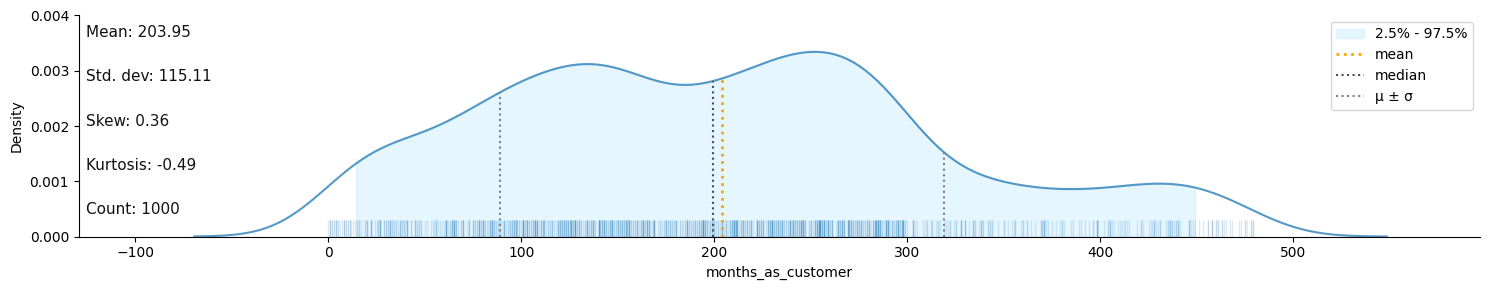

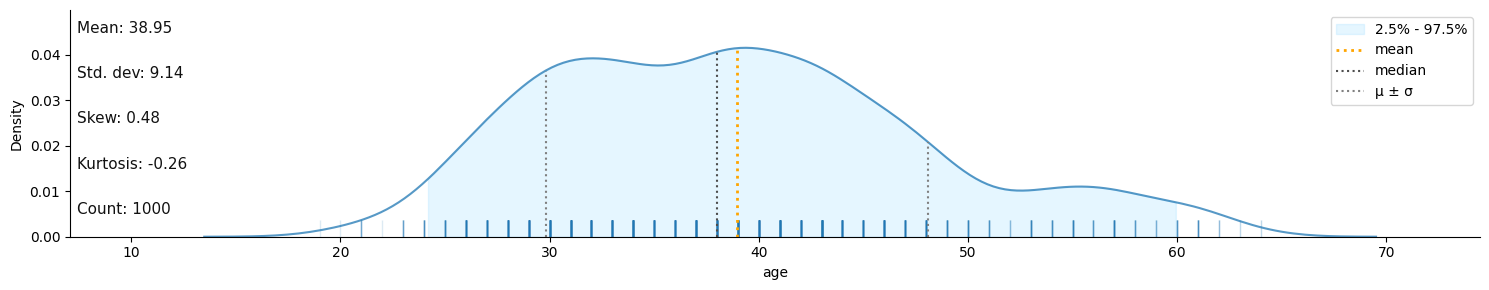

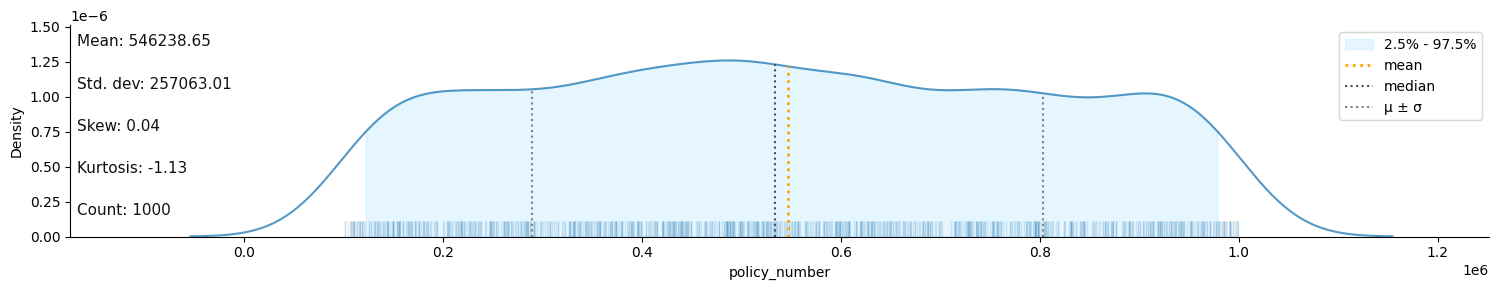

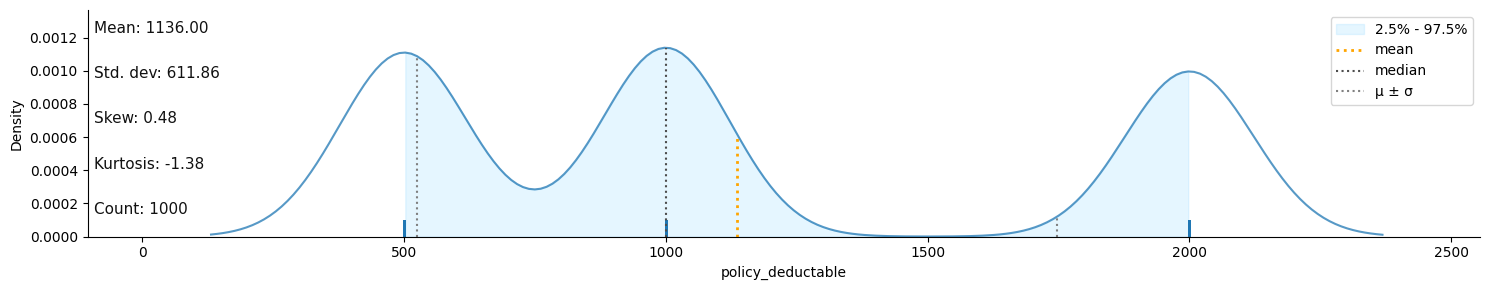

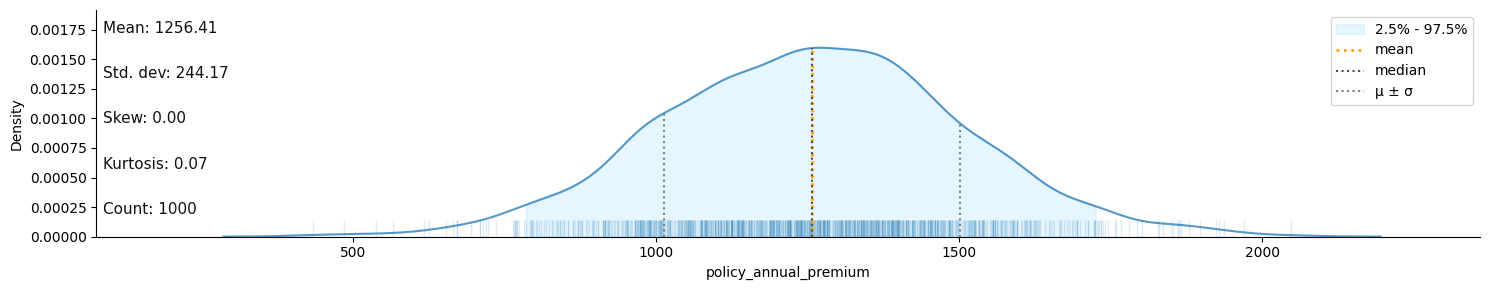

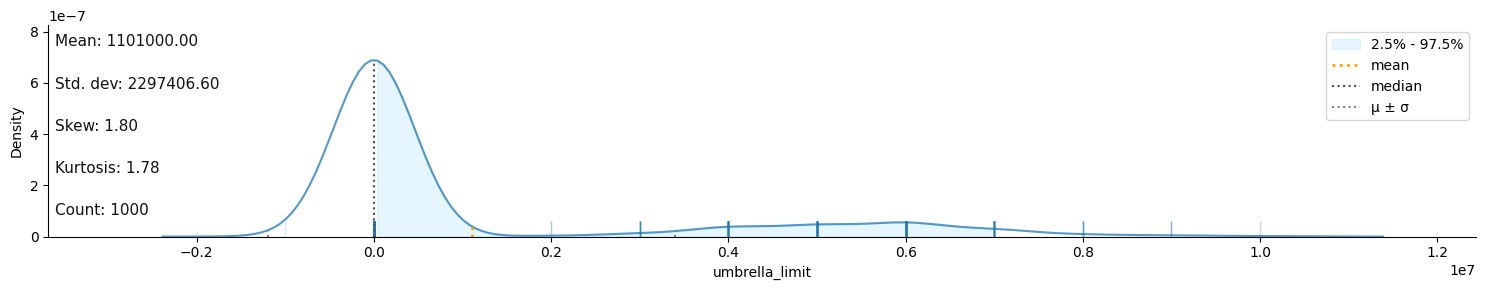

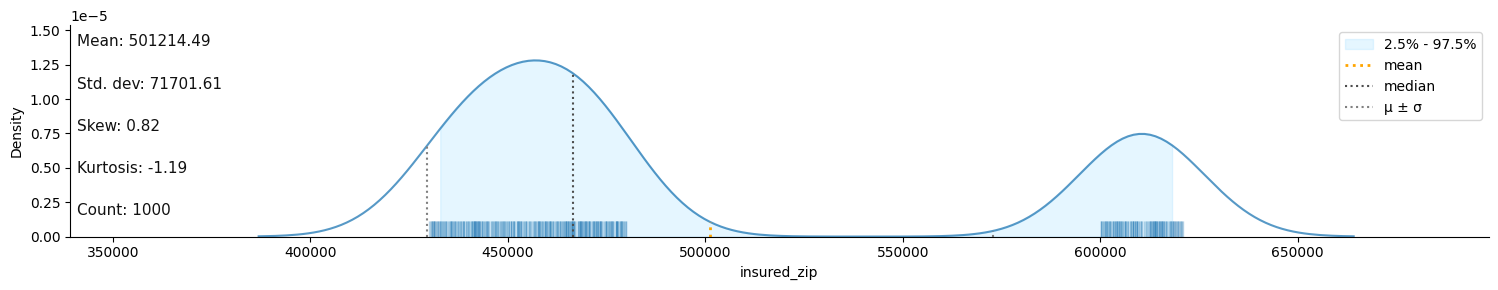

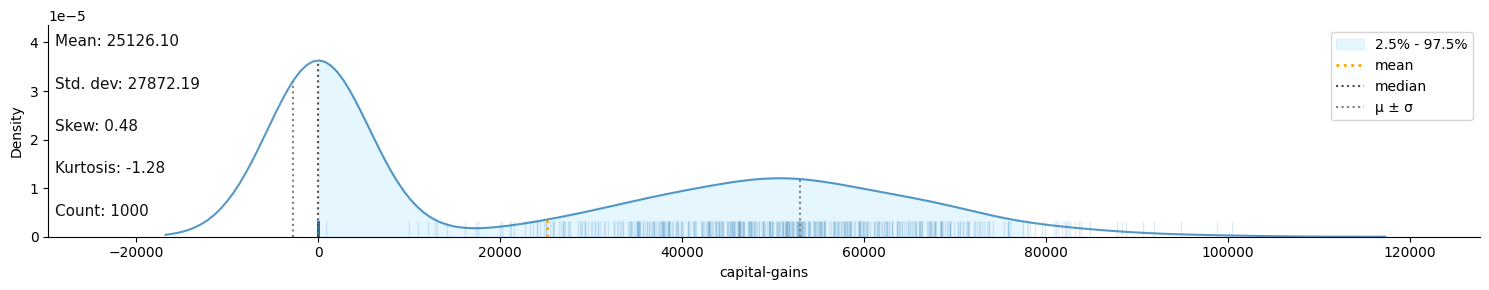

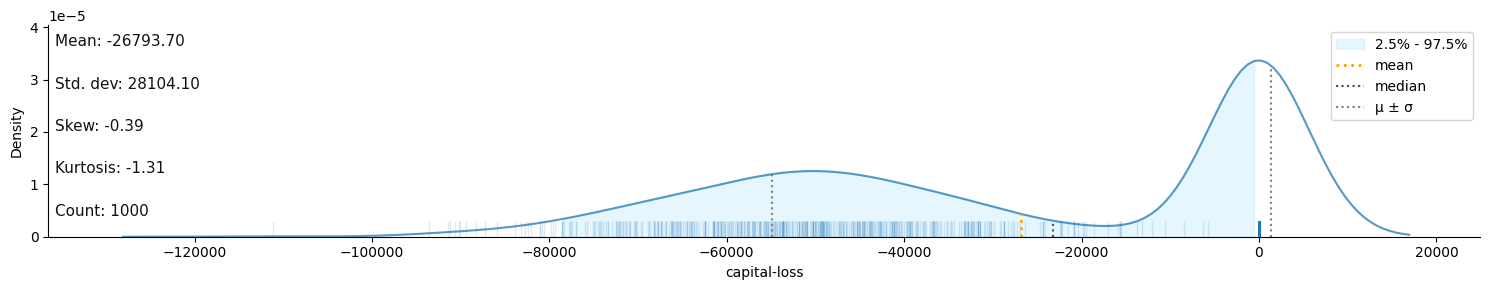

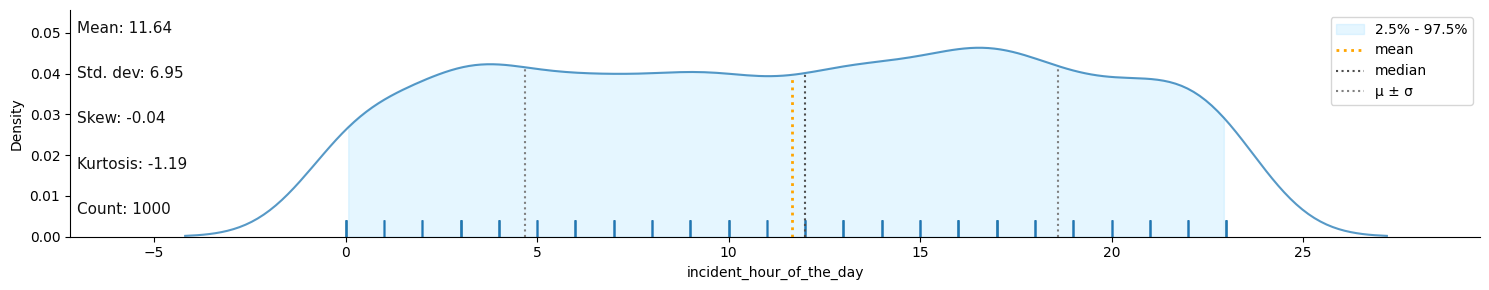

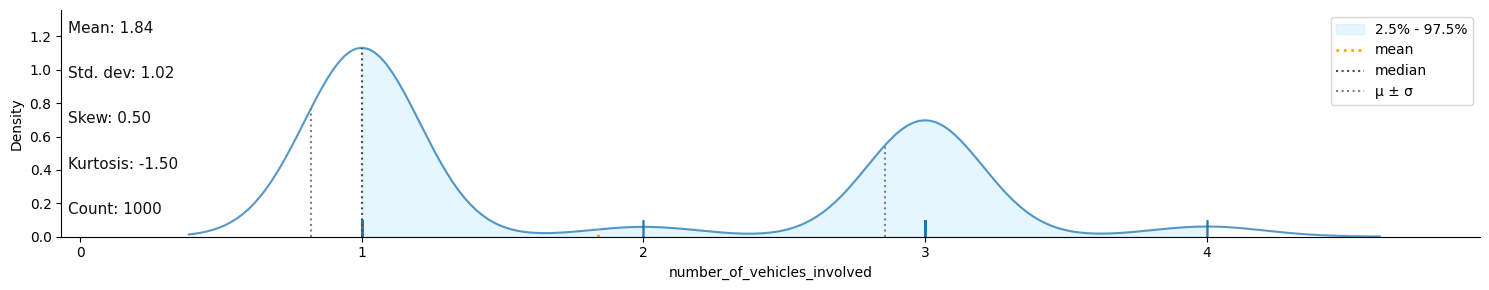

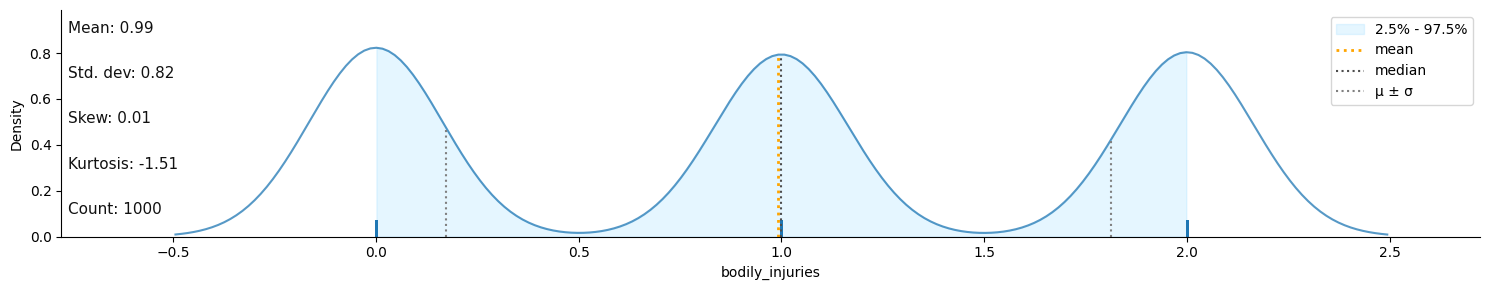

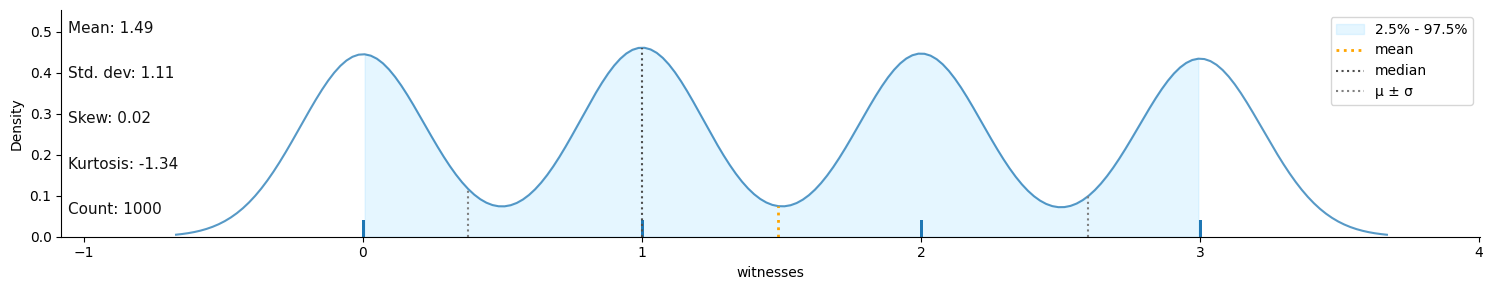

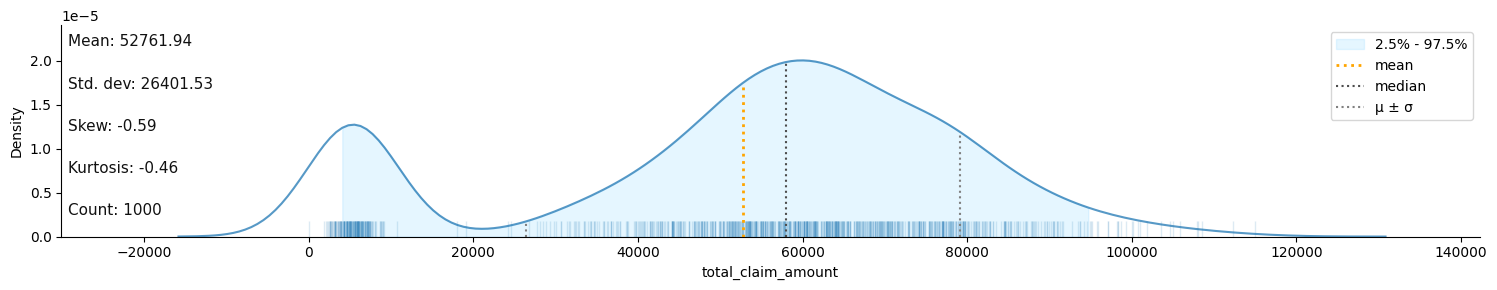

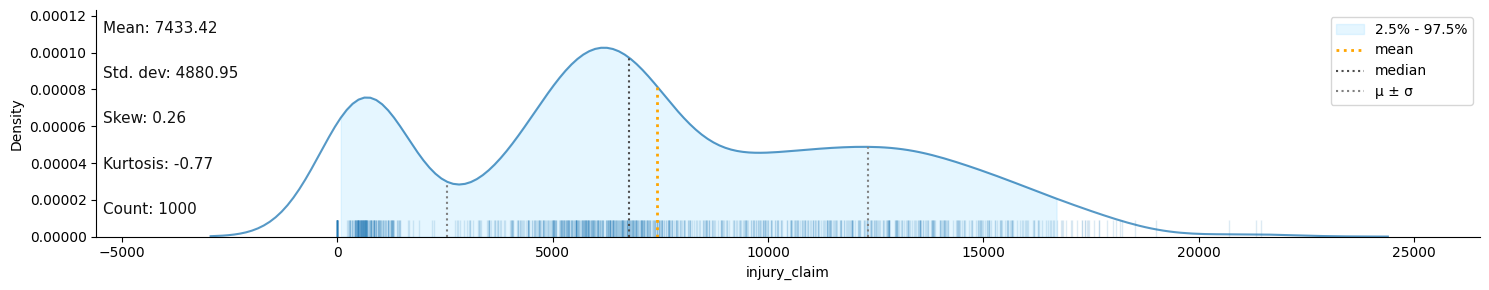

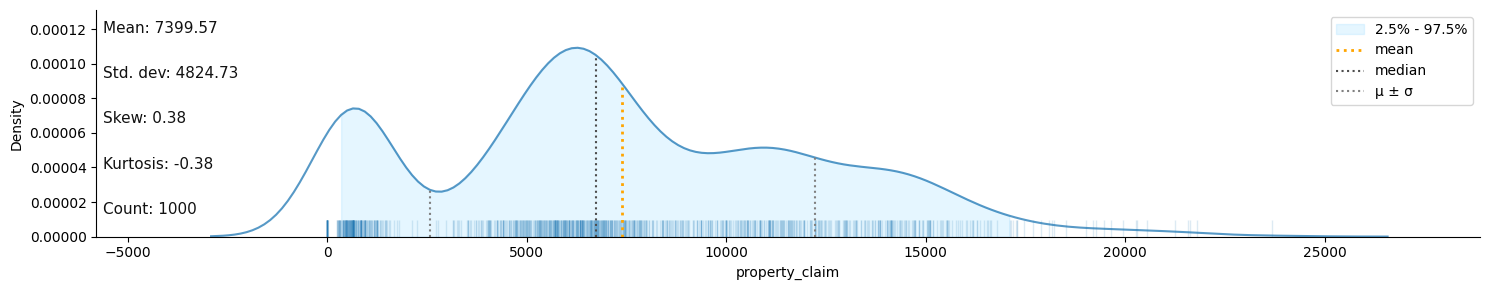

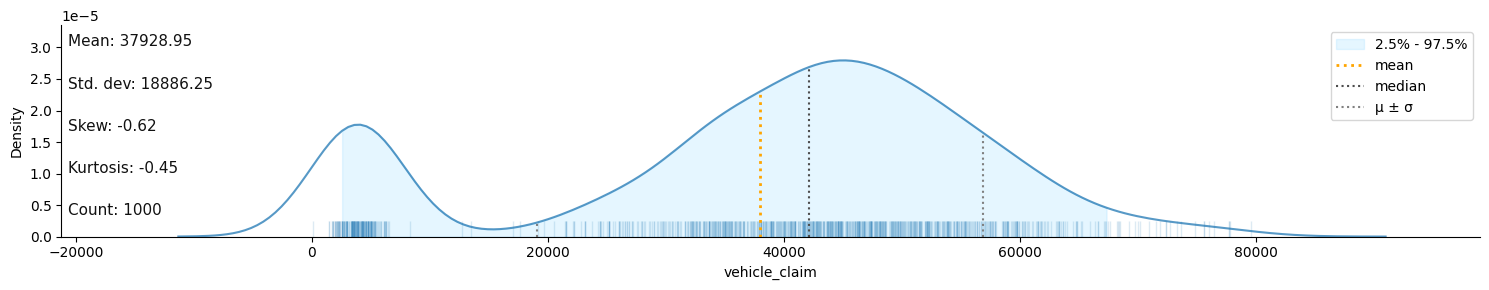

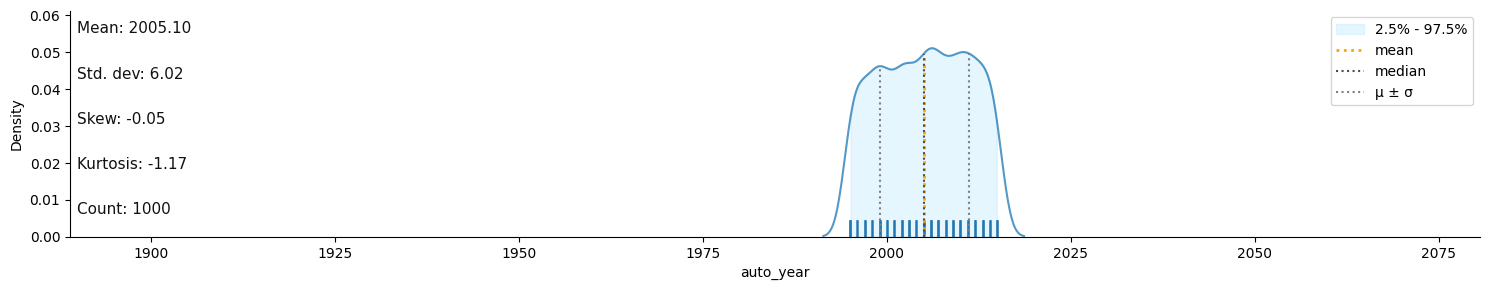

In [ ]:
import klib
klib.dist_plot(df)

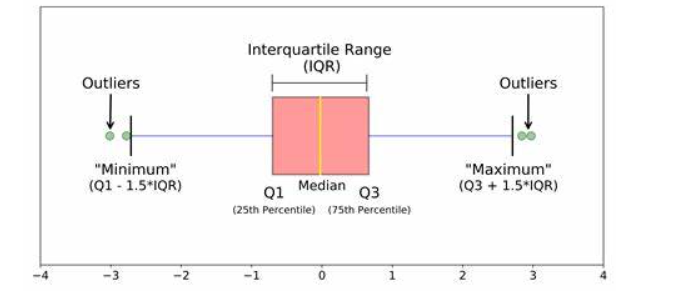

We will use sns.boxplot which displays the five-number summary of a numeric feature. The five numbers are minimum, first quartile (Q1 or 25% mark),median (Q2), third quartile (Q3 or 75% mark), and maximum

Here, we will separate the data by the target feature and observe how the numeric features are distributed among those which fraud (target = 1) and those which non-fraud (target = 0).

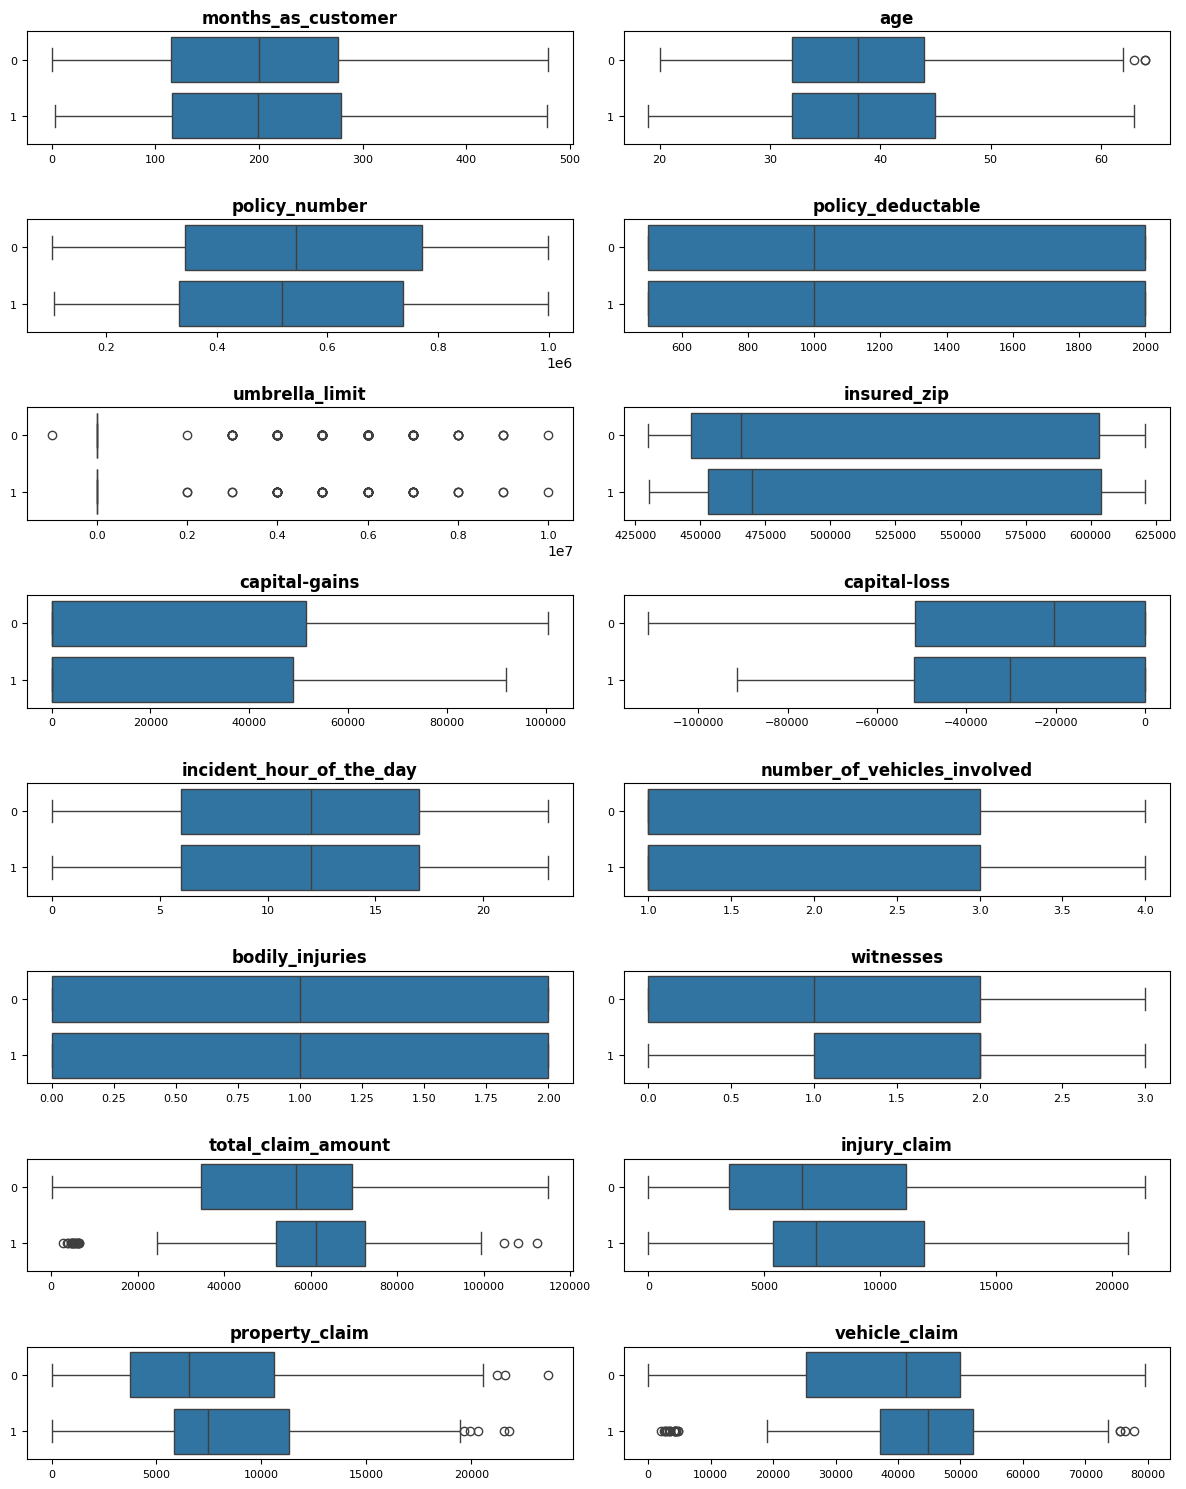

In [ ]:
list_num_col = []

for col in df.columns:
    if (df[col].dtype =='int'):
        list_num_col.append(col)

fig, axs = plt.subplots(len(list_num_col) // 2, 2, figsize=(12,15))
count = 0

train_set_box = df.copy()
train_set_box.fraud_reported = train_set_box.fraud_reported.map(dict(Y=1,N=0))


for i in range(len(list_num_col) // 2):
    for j in range(2):

        if count >= len(list_num_col):
            break

        sns.boxplot(data = train_set_box, x=list_num_col[count], y='fraud_reported', ax=axs[i, j], orient='h')

        axs[i, j].tick_params(axis='x', labelsize=8)
        axs[i, j].tick_params(axis='y', labelsize=8)

        axs[i, j].set_xlabel('')
        axs[i, j].set_ylabel('')
        axs[i, j].set_title(list_num_col[count], fontweight='bold')
        # axs[i, j].legend(loc='upper right')

        count += 1

# fig.legend(['N','Y'], loc='upper right', title='fraud_reported')

plt.tight_layout()
plt.show()

We can see that month_as_customers, age, insured_zip, capital_gains, capital_loss, incident_hours_of_the_day
are almost equally distributed among those which non-fraud (target 0) and those which fraud (target 1).
This means that training_hours might not be a good predictor for the target.

However, we see that when it comes to policy_annual_premium, total_claim_amount, injury_claim, property_claim, vehicle_claim,
a bigger proportion of those who stayed are tending towards more years of experience and these could be good predictors

Now that we have seen how the target changes with numeric features, we will do the same for categorical features.

pd.crosstab(col1, col2) function builds a cross-tabulation table that shows the relationship between two categorical features. The table shows the frequency by which groups of data from the two features appear. You can include the parameter normalize='index' to show the percentages

Here, loop through 4 categorical columns (those with less than 5 unique classes).

In [ ]:
list_cat_col = []

for col in df.columns:
    if (df[col].dtype =='object'):
        list_cat_col.append(col)

In [ ]:
for col in list_cat_col:
  if df[col].nunique() <=4:
    display(pd.crosstab(df.fraud_reported , df[col] , normalize = 'index'))
    print("-----------------------------------------------------------------------------------------------------")

policy_state,IL,IN,OH
fraud_reported,,,
N,0.346614,0.306773,0.346614
Y,0.311741,0.319838,0.368421


-----------------------------------------------------------------------------------------------------


policy_csl,100/300,250/500,500/1000
fraud_reported,,,
N,0.343958,0.343958,0.312085
Y,0.364372,0.372470,0.263158


-----------------------------------------------------------------------------------------------------


insured_sex,FEMALE,MALE
fraud_reported,,
N,0.545817,0.454183
Y,0.510121,0.489879


...

-----------------------------------------------------------------------------------------------------


police_report_available,?,NO,YES
fraud_reported,,,
N,0.337317,0.341301,0.321381
Y,0.360324,0.348178,0.291498


-----------------------------------------------------------------------------------------------------


fraud_reported,N,Y
fraud_reported,,
N,1.0,0.0
Y,0.0,1.0


-----------------------------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:453: RuntimeWarning:

More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.



<Figure size 1200x300 with 0 Axes>

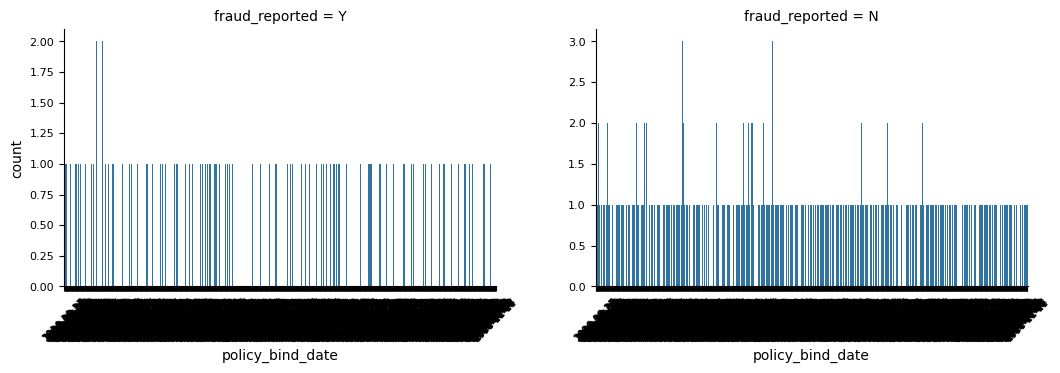

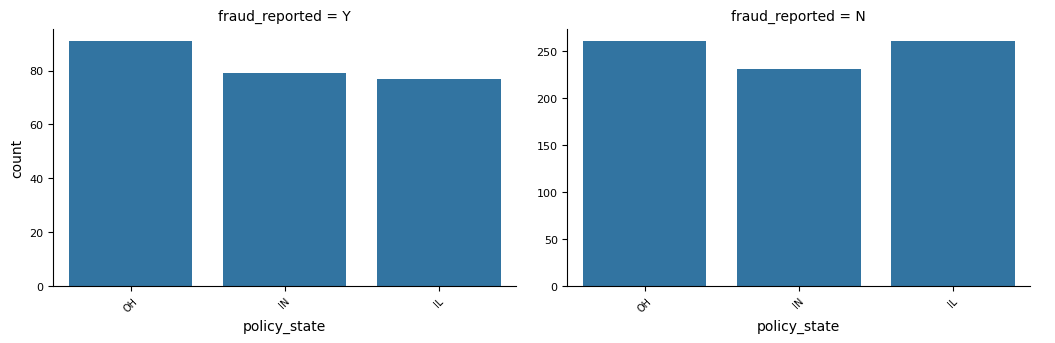

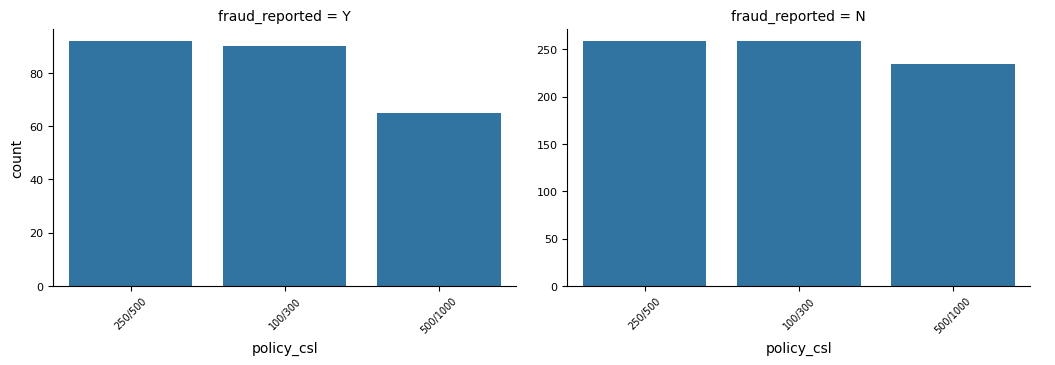

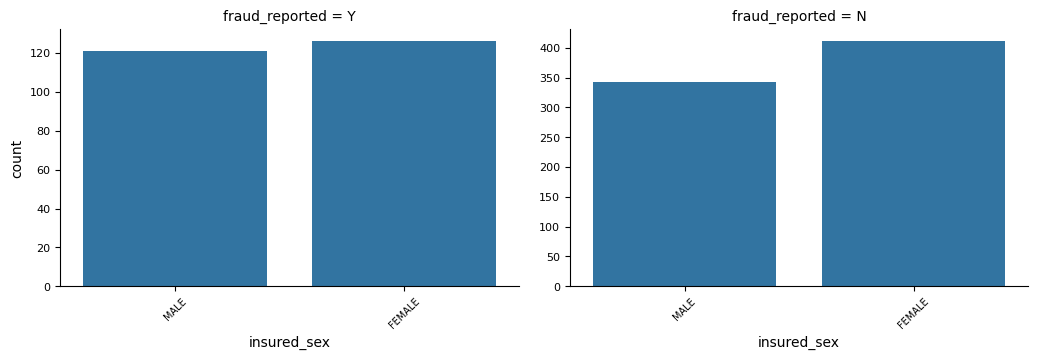

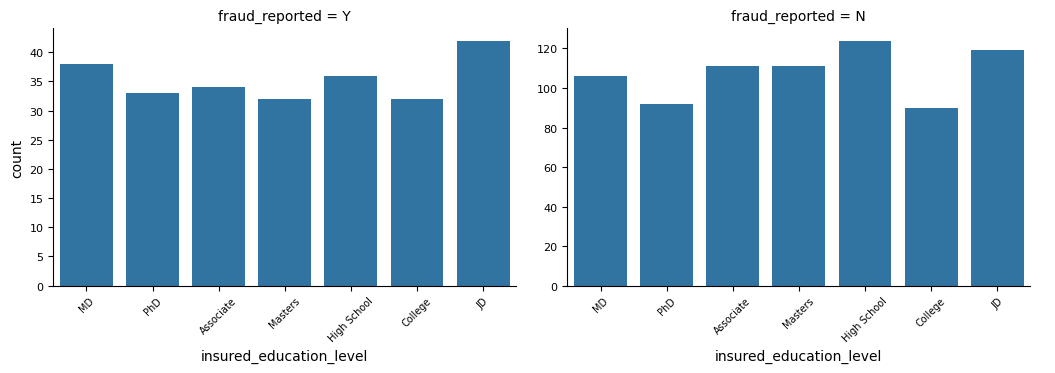

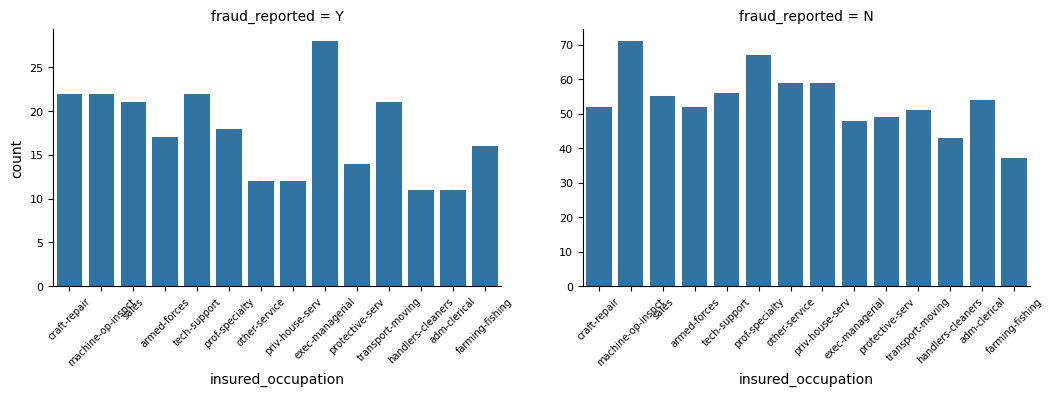

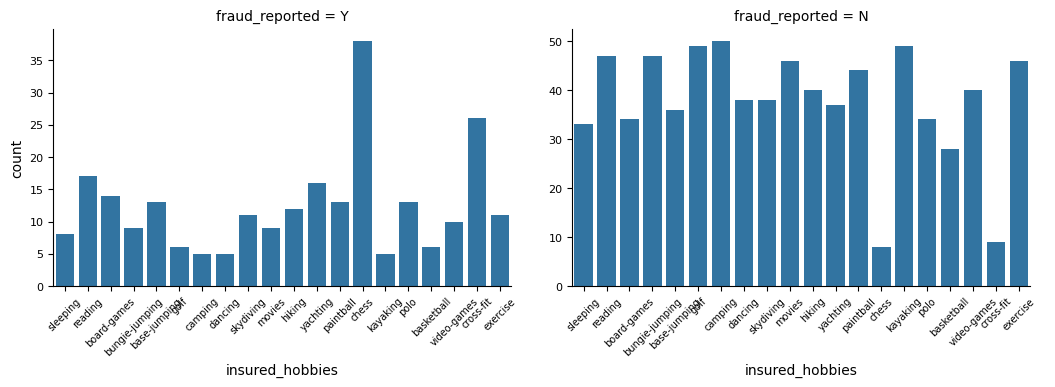

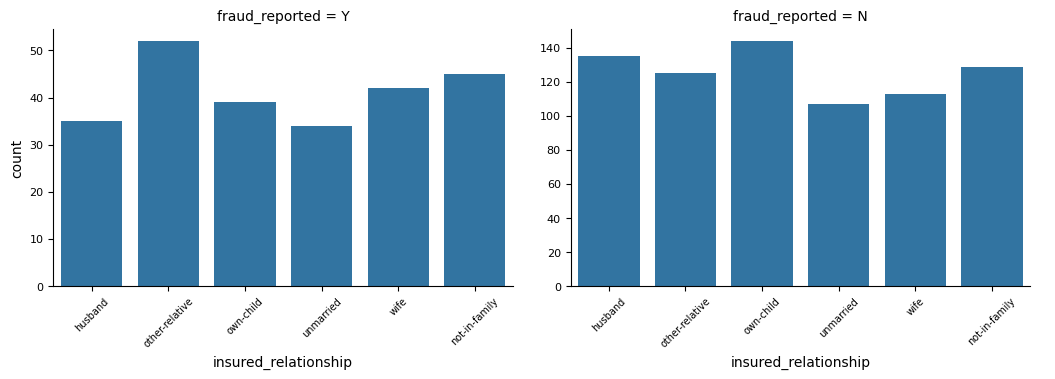

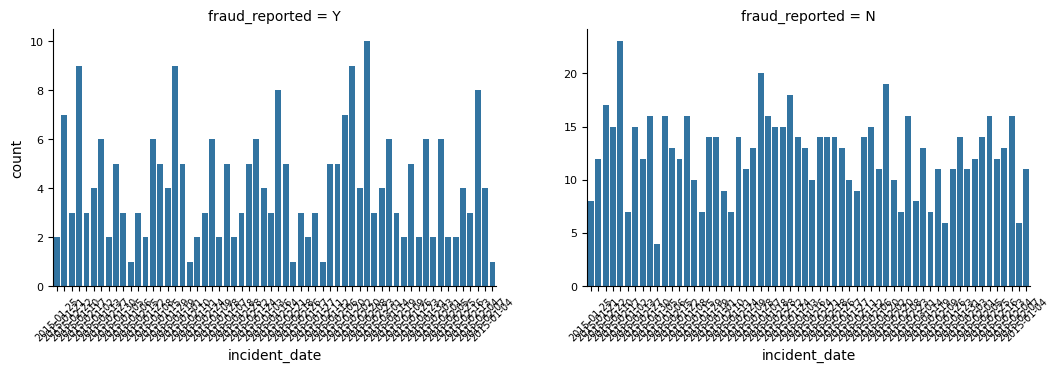

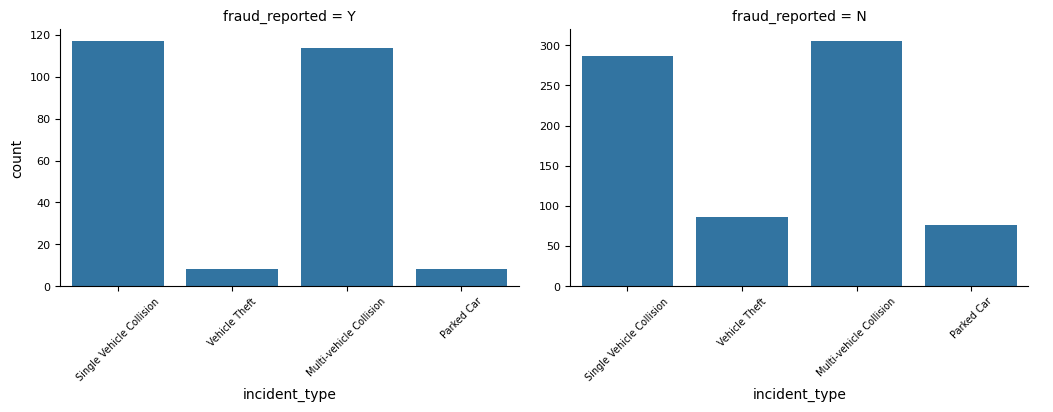

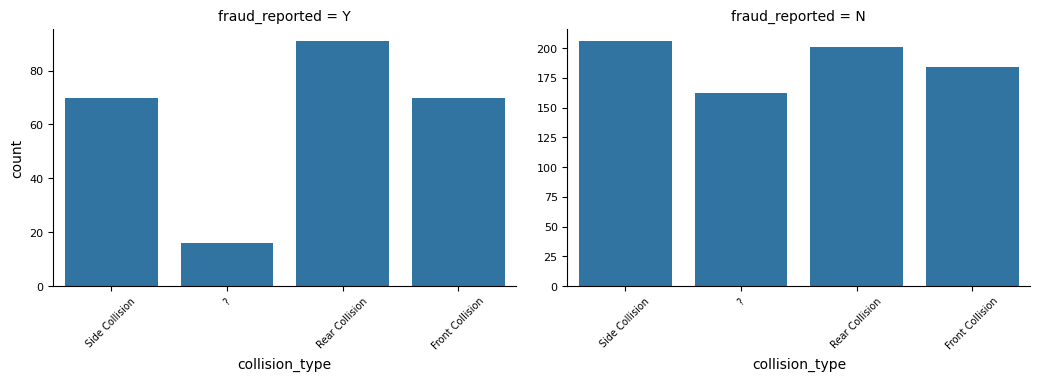

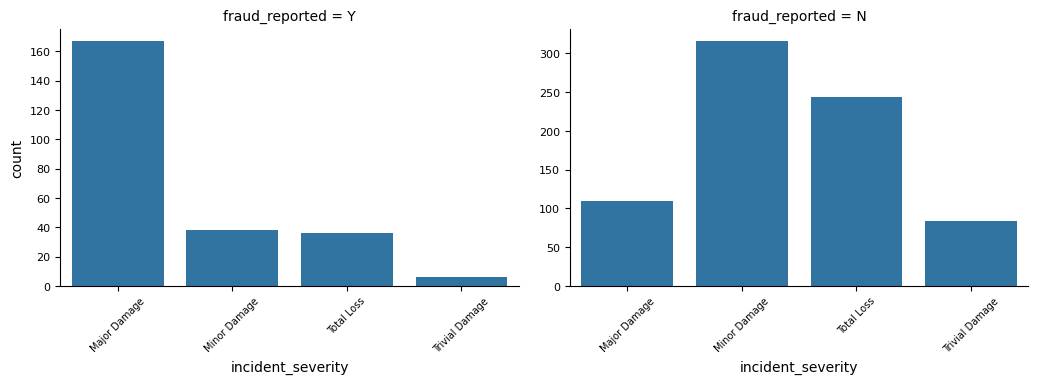

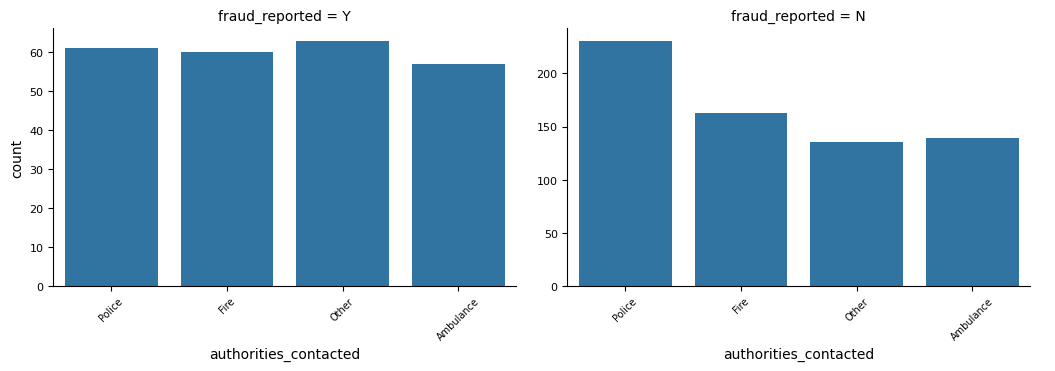

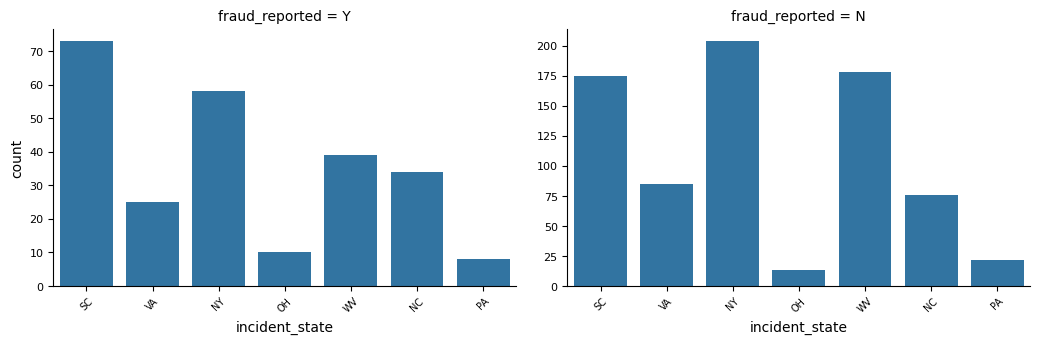

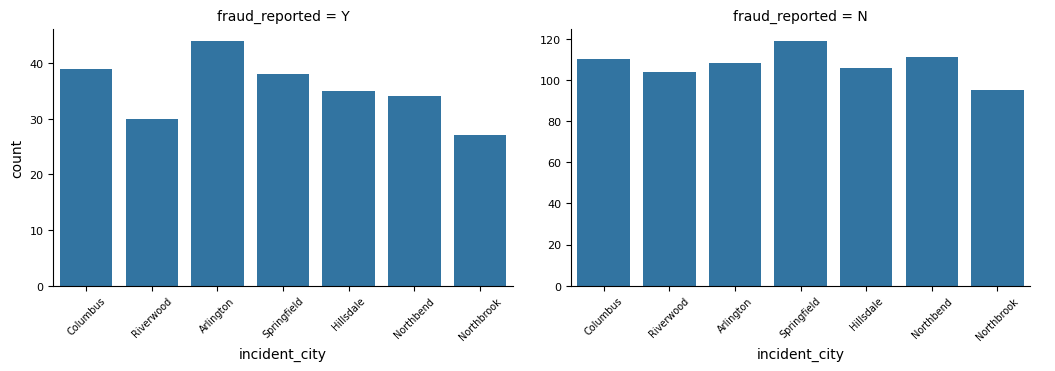

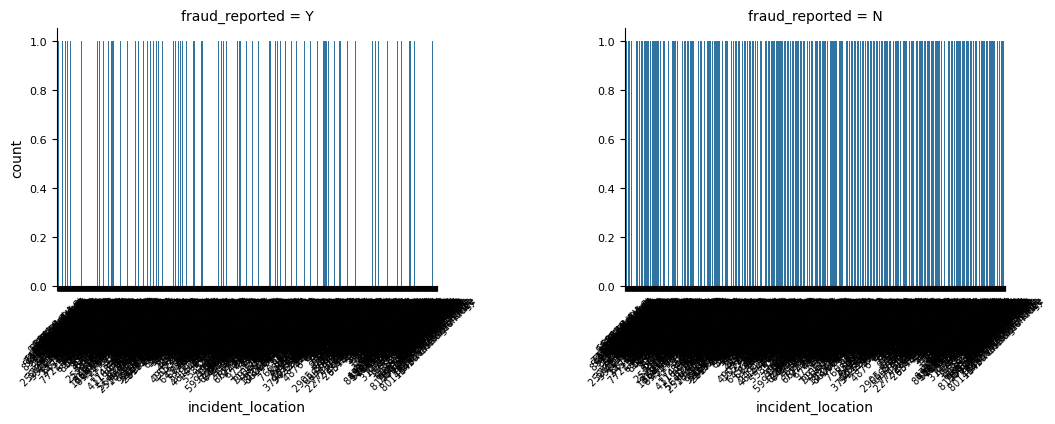

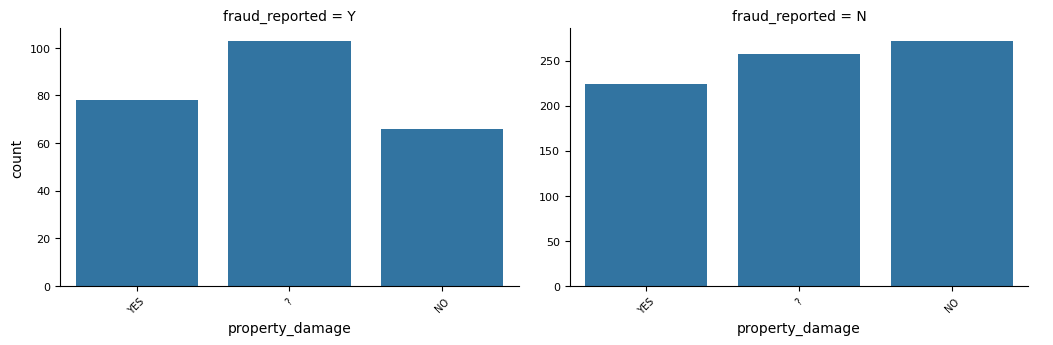

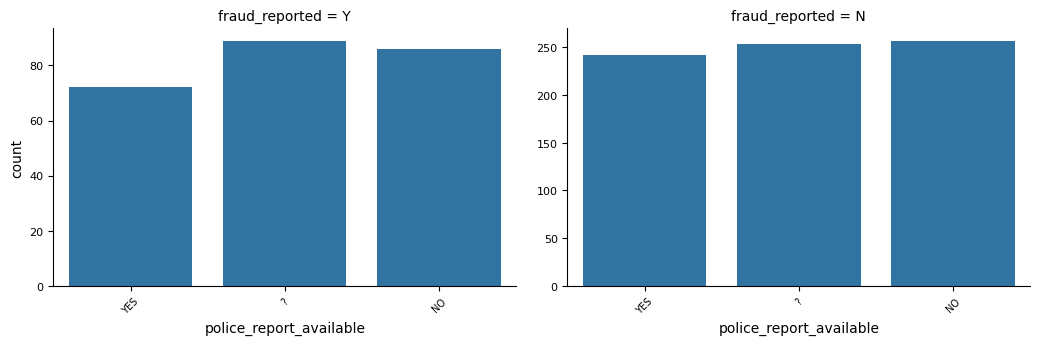

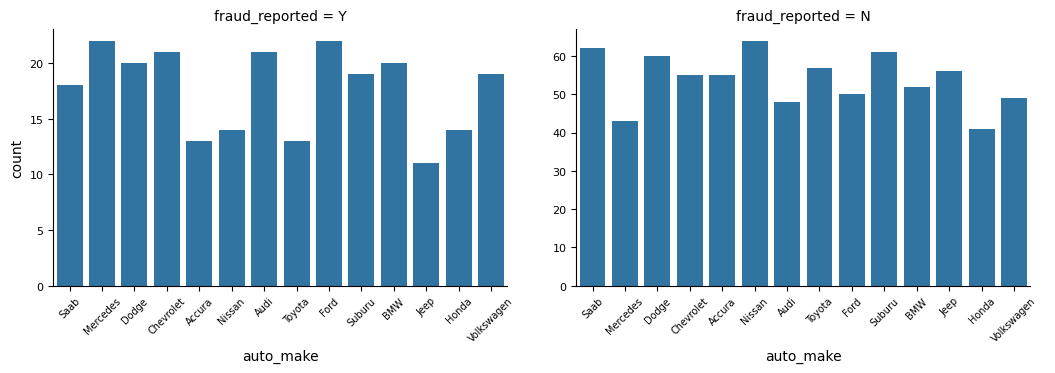

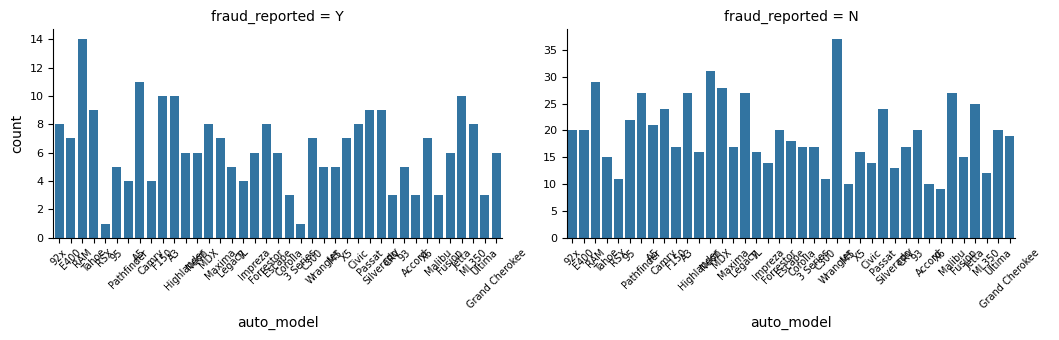

In [ ]:
list_cat_col = []

for col in df.columns:
    if (df[col].dtype =='object'):
        list_cat_col.append(col)

plt.figure(figsize=(12, 3))
count = 0

for i in range(len(list_cat_col) // 2):
    for j in range(2):

        if count >= len(list_cat_col):
            break

        c = sns.catplot(data = df, x = list_cat_col[count], col='fraud_reported', kind='count',
                        sharey=False, height=3.5, aspect=1.5)

        c.tick_params(axis='x', labelsize=8)
        c.tick_params(axis='y', labelsize=8)
        c.set_xticklabels(rotation=45, fontsize=7)

        count += 1

plt.tight_layout()
plt.show()

In [ ]:
trace = go.Pie(labels = df["insured_sex"].value_counts().keys().tolist(),
               values = df["insured_sex"].value_counts().values.tolist(),
               marker = dict(colors = ["lightblue" , "lime"],
                             line = dict(color = "white" , width = 1.3)
                             ),
               rotation = 30,
               hoverinfo="label+value+text",
               hole = .5
               )


layout = go.Layout(dict(title = "Distribution of Insured Sex Data",
                        plot_bgcolor = "rgb(243,243,243)",
                        paper_bgcolor = "rgb(243,243,243)",
                       )
                  )
data = [trace]
fig = go.Figure(data = data, layout = layout)
py.iplot(fig)


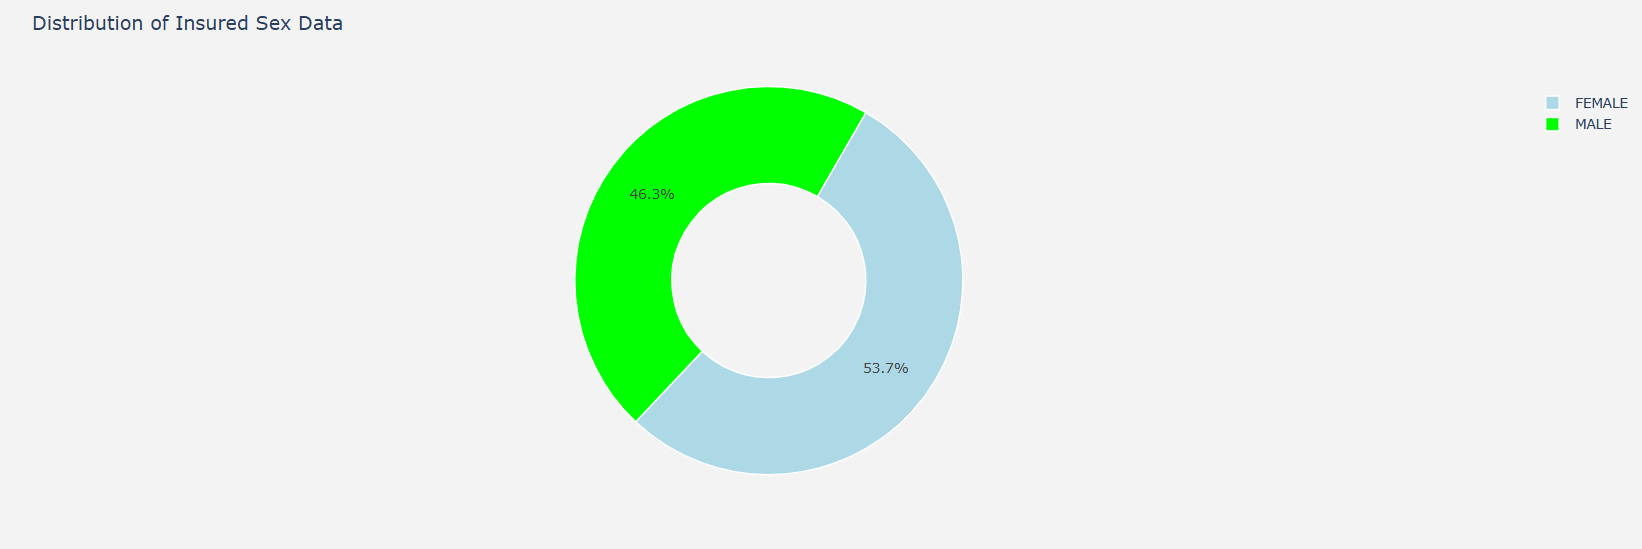

In [ ]:
trace = go.Pie(labels = df["insured_occupation"].value_counts().keys().tolist(),
               values = df["insured_occupation"].value_counts().values.tolist(),
               marker = dict(colors = ["lightblue" , "lime"],
                             line = dict(color = "white" , width = 1.3)
                             ),
               rotation = 30,
               hoverinfo="label+value+text",
               hole = .5
               )


layout = go.Layout(dict(title = "Distrubution of insured occupation",
                        plot_bgcolor = "rgb(243,243,243)",
                        paper_bgcolor = "rgb(243,243,243)",
                       )
                  )
data = [trace]
fig = go.Figure(data = data, layout = layout)
py.iplot(fig)


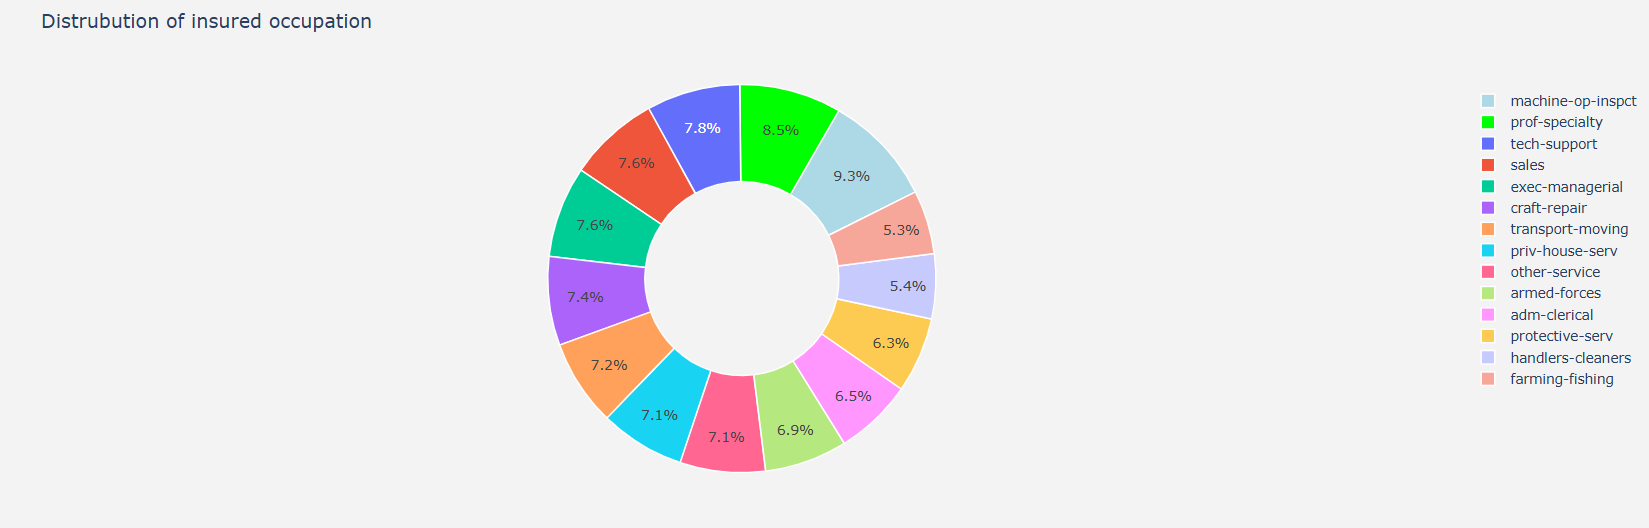

In [ ]:
trace = go.Pie(labels = df["auto_make"].value_counts().keys().tolist(),
               values = df["auto_make"].value_counts().values.tolist(),
               marker = dict(colors = ["lightblue" , "lime"],
                             line = dict(color = "white" , width = 1.3)
                             ),
               rotation = 30,
               hoverinfo="label+value+text",
               hole = .5
               )


layout = go.Layout(dict(title = "Distribution of auto make  Data",
                        plot_bgcolor = "rgb(243,243,243)",
                        paper_bgcolor = "rgb(243,243,243)",
                       )
                  )
data = [trace]
fig = go.Figure(data = data, layout = layout)
py.iplot(fig)


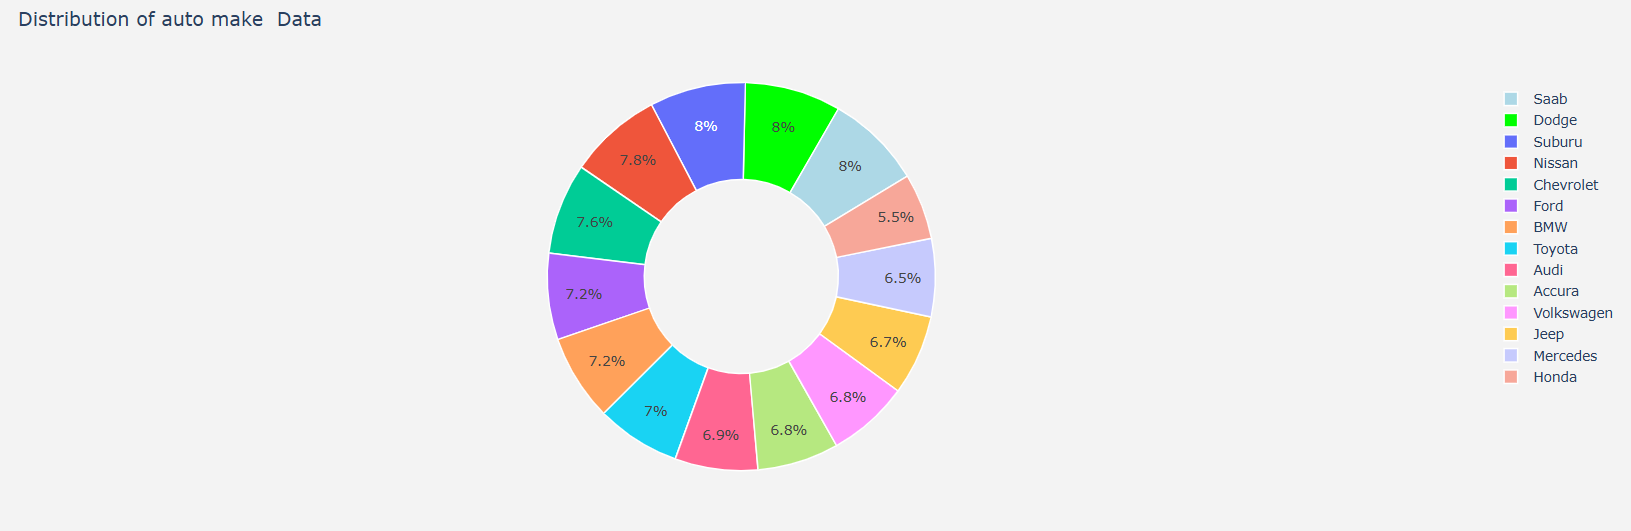

In [ ]:
trace = go.Pie(labels = df["fraud_reported"].value_counts().keys().tolist(),
               values = df["fraud_reported"].value_counts().values.tolist(),
               marker = dict(colors = ["lightblue" , "lime"],
                             line = dict(color = "white" , width = 1.3)
                             ),
               rotation = 30,
               hoverinfo="label+value+text",
               hole = .5
               )


layout = go.Layout(dict(title = "Distribution of fraud reported  Data",
                        plot_bgcolor = "rgb(243,243,243)",
                        paper_bgcolor = "rgb(243,243,243)",
                       )
                  )
data = [trace]
fig = go.Figure(data = data, layout = layout)
py.iplot(fig)


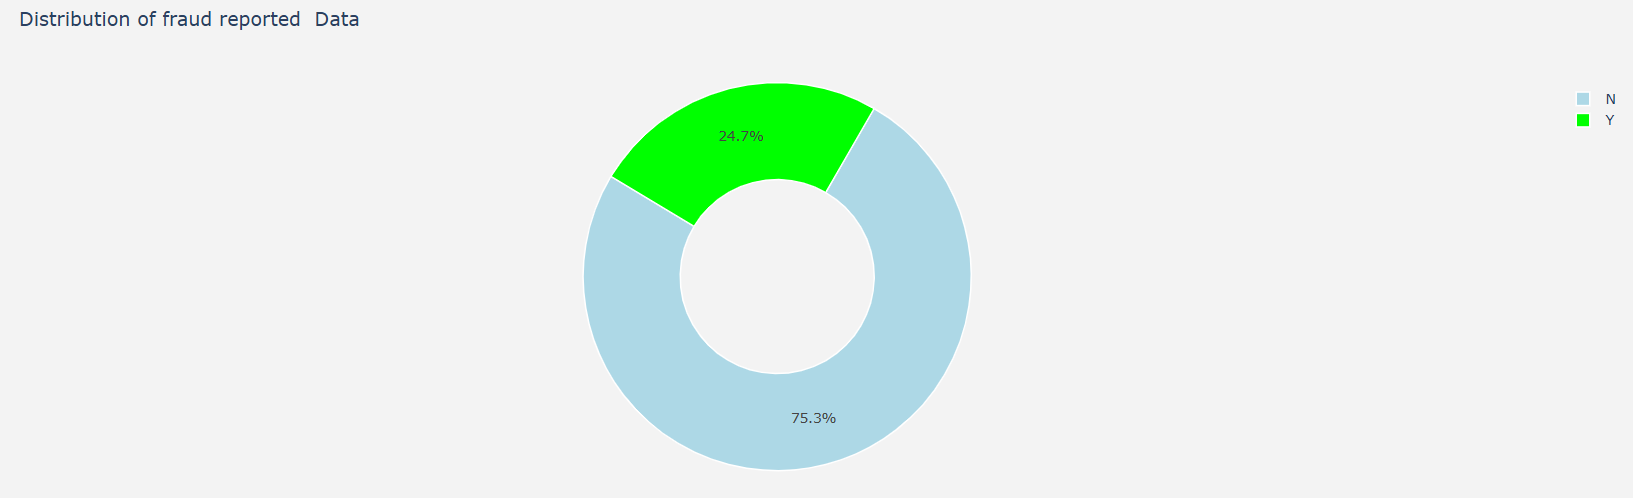

In [ ]:
df

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN
